# Opening the Black Box: Concept Activation Vectors (TCAV) & Network Dissection

**Dataset:** MNIST handwritten digits (60,000 train / 10,000 test, 28×28 grayscale)
**Framework:** PyTorch · **Runs on:** Google Colab or any laptop (CPU is fine, ~5 minutes end to end)

---

### Why this notebook?

A trained CNN can classify digits with 99% accuracy, but *what has it learned*? Two classic interpretability methods answer this from opposite directions:

| | **TCAV** (Kim et al., 2018) | **Network Dissection** (Bau et al., 2017) |
|---|---|---|
| Question asked | *"How much does a human concept (e.g. **circles**) matter for predicting class **0**?"* | *"What concept does **unit #17** in layer conv2 detect?"* |
| Direction | Concept → Model | Unit → Concept |
| Needs | A few example images of the concept | Pixel-level concept masks (segmentations) |
| Output | A score per (concept, class) | A label + IoU score per unit |

### Learning objectives
By the end you should be able to:
1. Extract intermediate activations from a CNN.
2. Train a **Concept Activation Vector (CAV)** and compute a **TCAV score** with a significance test.
3. Explain the **Network Dissection** pipeline: thresholding, upsampling and IoU.
4. Label individual units with human concepts and compare a trained vs an untrained network.

### Roadmap
0. Setup  1. Data & model  **Part A – TCAV**  **Part B – Network Dissection**  Exercises

## 0. Setup
Everything used here is pre-installed on Google Colab. Locally: `pip install torch torchvision scikit-learn scipy matplotlib`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from scipy import ndimage, stats
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# A small, colour-blind-friendly palette used for all plots
C_BLUE, C_ORANGE, C_AQUA, C_GRAY = "#2a78d6", "#eb6834", "#1baf7a", "#9a9a94"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 100})

Using device: cuda


## 1. Data and model

### 1.1 Load MNIST
We normalise with the standard MNIST mean (0.1307) and std (0.3081). We keep a helper `normalize()` because later we will feed our **own synthetic images** into the network and they must be preprocessed exactly like the real data.

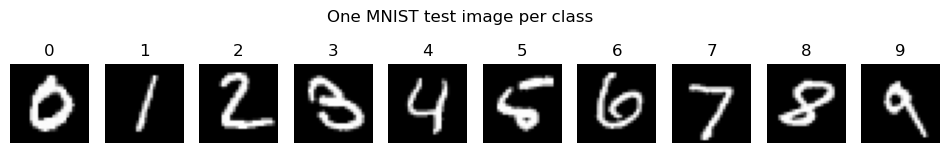

In [2]:
MEAN, STD = 0.1307, 0.3081
def normalize(x):          # x: tensor in [0, 1]
    return (x - MEAN) / STD

tfm = transforms.Compose([transforms.ToTensor(), transforms.Normalize((MEAN,), (STD,))])
train_ds = datasets.MNIST("./data", train=True,  download=True, transform=tfm)
test_ds  = datasets.MNIST("./data", train=False, download=True, transform=tfm)

train_loader = torch.utils.data.DataLoader(train_ds, batch_size=128, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_ds,  batch_size=512, shuffle=False)

# Raw test images in [0,1] and labels - handy for Part A and Part B
X_test_raw = test_ds.data.float() / 255.0        # (10000, 28, 28)
y_test     = test_ds.targets.clone()             # (10000,)

fig, axes = plt.subplots(1, 10, figsize=(12, 1.6))
for d, ax in enumerate(axes):
    idx = (y_test == d).nonzero()[0].item()
    ax.imshow(X_test_raw[idx], cmap="gray"); ax.set_title(str(d)); ax.axis("off")
plt.suptitle("One MNIST test image per class", y=1.08); plt.show()

### 1.2 A small CNN with "named" layers

Both methods need access to **internal activations**. Instead of hooks, we write the model so it can be split at any layer:

* `features_upto(x, layer)` – run the input up to `layer` and return its activation map **a = f_l(x)**
* `forward_from(a, layer)` – continue from that activation to the logits **h_l(a)**

So `model(x) == forward_from(features_upto(x, l), l)`. This split is exactly the notation used in the TCAV paper.

```
input 1×28×28
 └ conv1 (16 units) → ReLU  → 16×28×28   ← layer "conv1"
   └ maxpool → conv2 (32 units) → ReLU → 32×14×14   ← layer "conv2"
     └ maxpool → conv3 (64 units) → ReLU → 64×7×7   ← layer "conv3"
       └ flatten → fc(128) → fc(10)
```

In [3]:
class SmallCNN(nn.Module):
    LAYERS = ["conv1", "conv2", "conv3"]

    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool  = nn.MaxPool2d(2)
        self.fc1   = nn.Linear(64 * 7 * 7, 128)
        self.fc2   = nn.Linear(128, 10)

    def features_upto(self, x, layer):
        a = F.relu(self.conv1(x))
        if layer == "conv1": return a
        a = F.relu(self.conv2(self.pool(a)))
        if layer == "conv2": return a
        return F.relu(self.conv3(self.pool(a)))            # "conv3"

    def forward_from(self, a, layer):
        if layer == "conv1":
            a = F.relu(self.conv2(self.pool(a))); layer = "conv2"
        if layer == "conv2":
            a = F.relu(self.conv3(self.pool(a)))
        a = torch.flatten(a, 1)
        return self.fc2(F.relu(self.fc1(a)))

    def forward(self, x):
        return self.forward_from(self.features_upto(x, "conv3"), "conv3")

model = SmallCNN().to(device)
print(model)

SmallCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


### 1.3 Train (2 epochs are enough for ~98–99% test accuracy)

In [4]:
def evaluate(net):
    net.eval(); correct = 0
    with torch.no_grad():
        for x, y in test_loader:
            correct += (net(x.to(device)).argmax(1).cpu() == y).sum().item()
    return correct / len(test_ds)

opt = torch.optim.Adam(model.parameters(), lr=1e-3)
EPOCHS = 2
for epoch in range(EPOCHS):
    model.train()
    for i, (x, y) in enumerate(train_loader):
        x, y = x.to(device), y.to(device)
        loss = F.cross_entropy(model(x), y)
        opt.zero_grad(); loss.backward(); opt.step()
        if i % 200 == 0:
            print(f"epoch {epoch+1}  step {i:4d}  loss {loss.item():.3f}")
    print(f"--> epoch {epoch+1} test accuracy: {evaluate(model):.4f}")
model.eval();

epoch 1  step    0  loss 2.291
epoch 1  step  200  loss 0.110
epoch 1  step  400  loss 0.036
--> epoch 1 test accuracy: 0.9843
epoch 2  step    0  loss 0.013
epoch 2  step  200  loss 0.061
epoch 2  step  400  loss 0.019
--> epoch 2 test accuracy: 0.9857


---
# Part A — Testing with Concept Activation Vectors (TCAV)

### A.0 The idea in four steps

**1. Collect concept examples.** A *concept* is defined simply by a set of images, e.g. 50 pictures of **rings**. We also need a set of **random** counter-examples.

**2. Learn the Concept Activation Vector (CAV).** Pass both sets through the network up to layer $l$ to get activations $f_l(x)$. Train a linear classifier to separate *concept* vs *random*. The vector **normal to the decision boundary**, pointing toward the concept, is the CAV $v_C^l$.

**3. Directional derivative (conceptual sensitivity).** For an input $x$ of class $k$, how does the class logit $h_{l,k}$ change if we nudge the activation *in the direction of the concept*?
$$S_{C,k,l}(x) = \nabla h_{l,k}\big(f_l(x)\big)\cdot v_C^l$$
$S>0$ means "adding more of the concept would increase the score for class $k$".

**4. TCAV score.** The fraction of class-$k$ inputs whose sensitivity is positive:
$$\text{TCAV}_{C,k,l} = \frac{\left|\{x\in X_k : S_{C,k,l}(x) > 0\}\right|}{|X_k|}\;\in[0,1]$$

**Statistical test.** A CAV can be learned even from meaningless sets! So we train many CAVs, each against a *different* random set, and compare their scores with CAVs learned between **two random sets** (a null distribution) using a t-test. Only concepts that differ significantly from random are trusted.

> 💡 Intuition: the CAV is a direction in the network's "thought space". TCAV asks whether moving along that direction pushes the prediction toward a class.

### A.1 Build concept image sets

MNIST has no concept labels, so we **draw** simple concept images ourselves (the original paper did the same with striped / dotted / zig-zag textures for the "zebra" class).

| Concept | What we draw | Hypothesis |
|---|---|---|
| `ring` | closed circles/ellipses | important for **0** (maybe 6, 8, 9) |
| `horizontal` | horizontal bars | important for **7**, 4, 2 (top bar / cross bar) |
| `vertical` | vertical bars | important for **1** (and 4, 7) |
| `random` | random strokes at random angles | counter-examples (no specific concept) |

Every image is drawn on a 28×28 canvas, slightly blurred to look like pen strokes, and normalised like MNIST.

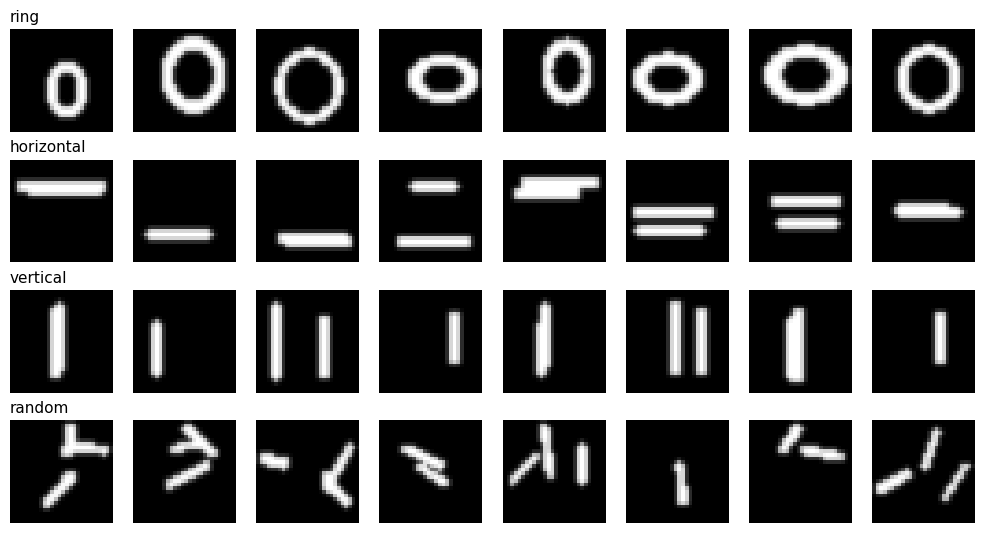

In [5]:
rng = np.random.default_rng(SEED)
H = W = 28

def _finish(img):
    img = ndimage.gaussian_filter(img, sigma=0.6)        # soften like a pen stroke
    return np.clip(img / (img.max() + 1e-8), 0, 1)

def draw_line(img, r0, c0, r1, c1, thick):
    for t in np.linspace(0, 1, 60):
        r, c = r0 + t * (r1 - r0), c0 + t * (c1 - c0)
        rr, cc = np.ogrid[:H, :W]
        img[(rr - r) ** 2 + (cc - c) ** 2 <= (thick / 2) ** 2] = 1.0
    return img

def make_ring():
    img = np.zeros((H, W))
    rr, cc = np.ogrid[:H, :W]
    r0, c0 = 14 + rng.integers(-3, 4), 14 + rng.integers(-3, 4)
    a, b = rng.uniform(5, 9), rng.uniform(4, 9)            # ellipse radii
    th = rng.uniform(2.5, 3.5)
    d = np.sqrt(((rr - r0) / a) ** 2 + ((cc - c0) / b) ** 2)
    img[np.abs(d - 1) < th / (2 * min(a, b))] = 1.0
    return _finish(img)

def make_horizontal():
    img = np.zeros((H, W))
    for _ in range(rng.integers(1, 3)):
        r = rng.integers(5, 23); c0 = rng.integers(3, 10); c1 = rng.integers(18, 25)
        draw_line(img, r, c0, r, c1, rng.uniform(2, 3.5))
    return _finish(img)

def make_vertical():
    img = np.zeros((H, W))
    for _ in range(rng.integers(1, 3)):
        c = rng.integers(5, 23); r0 = rng.integers(3, 10); r1 = rng.integers(18, 25)
        draw_line(img, r0, c, r1, c, rng.uniform(2, 3.5))
    return _finish(img)

def make_random():
    img = np.zeros((H, W))
    for _ in range(rng.integers(1, 4)):                   # 1-3 strokes, any angle
        r0, c0 = rng.uniform(7, 21, size=2)
        ang, L = rng.uniform(0, 2 * np.pi), rng.uniform(8, 16)
        r1 = np.clip(r0 + L * np.sin(ang), 2, 25); c1 = np.clip(c0 + L * np.cos(ang), 2, 25)
        draw_line(img, r0, c0, r1, c1, rng.uniform(2, 3.5))
    return _finish(img)

def make_set(fn, n):
    imgs = np.stack([fn() for _ in range(n)])[:, None]          # (n, 1, 28, 28)
    return normalize(torch.tensor(imgs, dtype=torch.float32))

N_CONCEPT = 100
concepts = {
    "ring":       make_set(make_ring, N_CONCEPT),
    "horizontal": make_set(make_horizontal, N_CONCEPT),
    "vertical":   make_set(make_vertical, N_CONCEPT),
}
N_RANDOM_SETS = 10                                  # needed for the significance test
random_sets = [make_set(make_random, N_CONCEPT) for _ in range(N_RANDOM_SETS)]

# Visualise
fig, axes = plt.subplots(4, 8, figsize=(10, 5.4))
for row, (name, imgs) in enumerate(list(concepts.items()) + [("random", random_sets[0])]):
    for j in range(8):
        axes[row, j].imshow(imgs[j, 0] * STD + MEAN, cmap="gray", vmin=0, vmax=1)
        axes[row, j].axis("off")
    axes[row, 0].set_title(name, loc="left", fontsize=11)
plt.tight_layout(); plt.show()

### A.2 Get activations and learn a CAV

We flatten the activation map of a layer (e.g. conv2 has 32×14×14 = 6,272 numbers) and fit a logistic regression: **concept = 1, random = 0**.
The CAV is the (unit-length) weight vector of that classifier. We also report held-out accuracy — if the classifier can't separate the sets, the layer doesn't "represent" the concept.

In [6]:
@torch.no_grad()
def get_acts(x, layer, batch=256):
    out = [model.features_upto(x[i:i+batch].to(device), layer).flatten(1).cpu()
           for i in range(0, len(x), batch)]
    return torch.cat(out).numpy()

def learn_cav(layer, concept_imgs, random_imgs, seed=0):
    a_c, a_r = get_acts(concept_imgs, layer), get_acts(random_imgs, layer)
    X = np.concatenate([a_c, a_r]); y = np.r_[np.ones(len(a_c)), np.zeros(len(a_r))]
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=seed, stratify=y)
    clf = LogisticRegression(C=0.1, max_iter=2000).fit(Xtr, ytr)
    cav = clf.coef_[0] / np.linalg.norm(clf.coef_[0])      # points toward the concept
    return cav, clf.score(Xte, yte)

for layer in SmallCNN.LAYERS:
    accs = {name: learn_cav(layer, imgs, random_sets[0])[1] for name, imgs in concepts.items()}
    print(f"{layer}: CAV test accuracy -> " + ", ".join(f"{k}={v:.2f}" for k, v in accs.items()))

conv1: CAV test accuracy -> ring=0.95, horizontal=0.78, vertical=0.82
conv2: CAV test accuracy -> ring=1.00, horizontal=0.90, vertical=0.95
conv3: CAV test accuracy -> ring=1.00, horizontal=0.92, vertical=0.98


**Discussion:** accuracies are usually close to 1.0 — our concepts are visually very different from random strokes. High accuracy alone does **not** mean the concept matters for classification; that is what the directional derivative measures next.

### A.3 Directional derivatives and the TCAV score

For each image of the target class we:
1. compute the activation $a = f_l(x)$ and mark it `requires_grad`,
2. run the rest of the network $h_l(a)$ and back-propagate the **class-$k$ logit**,
3. take the dot product of the gradient with the CAV.

In [7]:
def class_grads(layer, k, n=300):
    # Gradient of logit_k w.r.t. layer activations, for n test images of class k
    x = normalize(X_test_raw[y_test == k][:n, None]).to(device)
    a = model.features_upto(x, layer).detach().requires_grad_(True)
    logit_k = model.forward_from(a, layer)[:, k]
    grad, = torch.autograd.grad(logit_k.sum(), a)
    return grad.flatten(1).cpu().numpy()                  # (n, D)

def tcav_score(grads, cav):
    return float(np.mean(grads @ cav > 0))

# Quick single example
layer, k = "conv2", 0
cav, acc = learn_cav(layer, concepts["ring"], random_sets[0])
g = class_grads(layer, k)
print(f"TCAV(ring -> class {k}, {layer}) = {tcav_score(g, cav):.2f}   (CAV accuracy {acc:.2f})")

TCAV(ring -> class 0, conv2) = 1.00   (CAV accuracy 1.00)


### A.4 Doing it properly: repeated runs + significance test

For every concept we learn **10 CAVs** (concept vs each of the 10 random sets). For the **null hypothesis** we learn 10 CAVs between two *different* random sets. Then we run a two-sided t-test on the two lists of TCAV scores:

* p < 0.05 → the concept's influence is **real** (show the bar)
* otherwise → indistinguishable from chance (grey it out)

In [8]:
def tcav_experiment(layer, classes=range(10)):
    # CAVs for each concept and for random-vs-random (null)
    cavs = {c: [learn_cav(layer, imgs, r, seed=i)[0] for i, r in enumerate(random_sets)]
            for c, imgs in concepts.items()}
    cavs["_null"] = [learn_cav(layer, random_sets[i], random_sets[(i + 1) % N_RANDOM_SETS], seed=i)[0]
                     for i in range(N_RANDOM_SETS)]
    results = {}                                            # (concept, class) -> (mean, std, p)
    for k in classes:
        g = class_grads(layer, k)
        null = [tcav_score(g, v) for v in cavs["_null"]]
        for c in concepts:
            s = [tcav_score(g, v) for v in cavs[c]]
            p = stats.ttest_ind(s, null).pvalue
            results[(c, k)] = (np.mean(s), np.std(s), p)
    return results

res = tcav_experiment("conv2")

C:\Users\nrmka\miniconda3\envs\myenv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


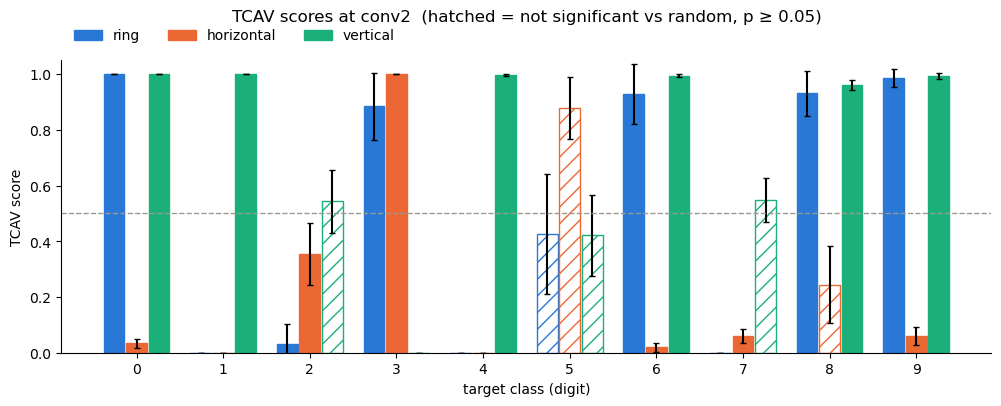

In [9]:
def plot_tcav(res, layer):
    names, colors = list(concepts), [C_BLUE, C_ORANGE, C_AQUA]
    fig, ax = plt.subplots(figsize=(12, 3.8)); w = 0.26
    for j, (c, col) in enumerate(zip(names, colors)):
        for k in range(10):
            m, s, p = res[(c, k)]
            sig = p < 0.05
            ax.bar(k + (j - 1) * w, m, w * 0.92, yerr=s, capsize=2,
                   color=col if sig else "white", edgecolor=col, hatch=None if sig else "//",
                   label=c if k == 0 else None)
    ax.axhline(0.5, color=C_GRAY, lw=1, ls="--")
    ax.set_xticks(range(10)); ax.set_xlabel("target class (digit)"); ax.set_ylabel("TCAV score")
    ax.set_ylim(0, 1.05); ax.legend(ncol=3, frameon=False, loc="upper left", bbox_to_anchor=(0, 1.15))
    ax.set_title(f"TCAV scores at {layer}  (hatched = not significant vs random, p ≥ 0.05)", pad=28)
    plt.show()

plot_tcav(res, "conv2")

### A.5 How to read the plot
* Score **near 1**: almost every image of that class becomes *more* likely when the concept is "added" → the model **uses** the concept positively.
* Score **near 0**: the concept consistently *reduces* the class logit (negative evidence — e.g. a ring is evidence *against* "1").
* **Hatched** bars: not statistically different from random CAVs → ignore them, however tall.

Compare the results with the hypotheses in the table of A.1. Do rings matter for 0? Horizontal bars for 7? Are there surprises?

### A.6 Does the answer depend on the layer?

In [ ]:
for layer in ["conv1", "conv3"]:
    plot_tcav(tcav_experiment(layer), layer)

**Things to notice**
* Early layers (conv1) encode local strokes/edges; a "ring" is a global shape, so conceptual sensitivity may be weaker or noisier there.
* Deeper layers are closer to the decision, so concept–class relationships tend to be sharper.
* TCAV is **global** (one number per class), **uses human-friendly concepts**, and needs **no retraining** of the model — its main strengths.
* Limitations: you must *choose* the concepts (you can only find what you look for), concept sets can be confounded (e.g. thickness or position), and results depend on the random sets → always use the significance test.

---
# Part B — Network Dissection

### B.0 The idea
TCAV starts from a concept. **Network Dissection** starts from a **single unit** (one channel of a conv layer) and asks which human concept it matches best.

The original work used the **Broden** dataset: 60k images with pixel-level masks for ~1,200 concepts (colours, textures, materials, parts, objects, scenes). The algorithm for each unit $k$:

1. **Collect activation maps** $A_k(x)$ for every image $x$ in the dataset.
2. **Threshold:** choose $T_k$ as the top quantile so that $P(A_k > T_k) = 0.005$ over all images and positions (the unit's "strongest 0.5%" responses).
3. **Upsample** $A_k(x)$ to the input resolution (bilinear) and binarise: $M_k(x) = A_k(x) \ge T_k$.
4. **Score each concept $c$** with Intersection-over-Union across the **whole dataset**, where $L_c(x)$ is the concept's ground-truth mask:
$$IoU_{k,c} = \frac{\sum_x |M_k(x) \cap L_c(x)|}{\sum_x |M_k(x) \cup L_c(x)|}$$
5. **Label** the unit with the concept of highest IoU; call it a *detector* if $IoU > 0.04$ (the paper's threshold).

```
image ──► CNN ──► activation map of unit k ──► upsample ──► threshold (top 0.5%) ──► binary mask M_k
                                                                                        │ IoU
concept segmentation L_c (e.g. "hole", "horizontal edge", "digit 7") ─────────────────────┘
```

### B.1 Build a "mini-Broden" for MNIST

We create pixel-level concept masks automatically from each image, mimicking Broden's hierarchy from low-level to object-level:

| Level (Broden analogue) | Concept | How the mask is computed |
|---|---|---|
| colour | `stroke` | pixels with intensity > 0.5 |
| colour | `background` | pixels with intensity < 0.1 |
| texture / edge | `h-edge` | strong vertical gradient (Sobel along rows) → horizontal edges |
| texture / edge | `v-edge` | strong horizontal gradient (Sobel along columns) → vertical edges |
| part | `hole` | enclosed background regions (inside loops of 0, 6, 8, 9, 4) |
| object | `digit-0` … `digit-9` | the stroke pixels, **only** in images of that class |

In [ ]:
N_DISSECT = 1000                                     # images used for dissection
Xd = X_test_raw[:N_DISSECT].numpy()                  # (N, 28, 28) in [0,1]
yd = y_test[:N_DISSECT].numpy()

def concept_masks(img, label):
    stroke = img > 0.5
    gy, gx = ndimage.sobel(img, axis=0), ndimage.sobel(img, axis=1)
    m = {
        "stroke":     stroke,
        "background": img < 0.1,
        "h-edge":     (np.abs(gy) > 1.0) & (np.abs(gy) > np.abs(gx)),
        "v-edge":     (np.abs(gx) > 1.0) & (np.abs(gx) > np.abs(gy)),
        "hole":       ndimage.binary_fill_holes(stroke) & ~stroke,
    }
    for d in range(10):
        m[f"digit-{d}"] = stroke if label == d else np.zeros_like(stroke)
    return m

CONCEPTS = list(concept_masks(Xd[0], yd[0]).keys())
L = np.stack([np.stack([concept_masks(im, lb)[c] for c in CONCEPTS]) for im, lb in zip(Xd, yd)])
L = torch.tensor(L)                                  # (N, n_concepts, 28, 28) bool
print("Concepts:", CONCEPTS)

# Show the masks for three example digits
show = [np.where(yd == d)[0][0] for d in (0, 4, 7)]
cols = ["image"] + CONCEPTS[:5] + ["digit-0/4/7"]
fig, axes = plt.subplots(3, len(cols), figsize=(12, 5.2))
for r, i in enumerate(show):
    axes[r, 0].imshow(Xd[i], cmap="gray")
    for j in range(5):
        axes[r, j + 1].imshow(L[i, j].float(), cmap="Blues")
    axes[r, 6].imshow(L[i, CONCEPTS.index(f"digit-{yd[i]}")].float(), cmap="Blues")
    for j, ax in enumerate(axes[r]):
        ax.axis("off")
        if r == 0: ax.set_title(cols[j], fontsize=10)
plt.tight_layout(); plt.show()

### B.2 The dissection algorithm

We implement the five steps in one function. To keep memory small, IoU is accumulated in mini-batches: we sum intersections and the sizes of both masks, then use $|M \cup L| = |M| + |L| - |M \cap L|$.

In [ ]:
@torch.no_grad()
def dissect(net, layer, quantile=0.995, iou_thresh=0.04, batch=200):
    net.eval()
    x = normalize(torch.tensor(Xd)[:, None]).to(device)

    # Step 1: activation maps for every image
    A = torch.cat([net.features_upto(x[i:i+batch], layer).cpu() for i in range(0, len(x), batch)])
    n_units = A.shape[1]

    # Step 2: per-unit threshold T_k = top 0.5% of all activations of that unit
    flat = A.transpose(0, 1).reshape(n_units, -1).numpy()
    T = torch.tensor(np.quantile(flat, quantile, axis=1), dtype=torch.float32)

    inter = torch.zeros(n_units, len(CONCEPTS)); size_M = torch.zeros(n_units)
    size_L = L.flatten(2).sum((0, 2)).float()                      # |L_c| summed over images
    for i in range(0, len(A), batch):
        # Step 3: upsample to 28x28 and binarise
        up = F.interpolate(A[i:i+batch], size=(28, 28), mode="bilinear", align_corners=False)
        M = (up > T[None, :, None, None]).flatten(2).float()      # (b, units, 784)
        Lb = L[i:i+batch].flatten(2).float()                       # (b, concepts, 784)
        # Step 4: accumulate intersections and mask sizes
        inter += torch.einsum("bup,bcp->uc", M, Lb)
        size_M += M.sum((0, 2))
    iou = inter / (size_M[:, None] + size_L[None, :] - inter + 1e-8)

    # Step 5: best concept for every unit
    best = iou.argmax(1)
    return [{"unit": u, "concept": CONCEPTS[best[u]], "iou": iou[u, best[u]].item(),
             "detector": iou[u, best[u]].item() > iou_thresh} for u in range(n_units)], A, T

dissection = {layer: dissect(model, layer) for layer in SmallCNN.LAYERS}

for layer, (rows, _, _) in dissection.items():
    print(f"\n=== {layer}: top 8 units by IoU ===")
    for r in sorted(rows, key=lambda r: -r["iou"])[:8]:
        print(f"  unit {r['unit']:2d}  ->  {r['concept']:<10s}  IoU = {r['iou']:.3f}")

### B.3 Look at what a unit sees

A label is only a hypothesis — always **look** at the evidence. For a unit we show its most strongly activating images, with the thresholded region $M_k(x)$ outlined in orange.

In [ ]:
def show_unit(layer, unit, n=8):
    rows, A, T = dissection[layer]
    top = A[:, unit].flatten(1).max(1).values.argsort(descending=True)[:n].tolist()
    fig, axes = plt.subplots(1, n, figsize=(1.5 * n, 1.9))
    for ax, i in zip(axes, top):
        up = F.interpolate(A[i:i+1, unit:unit+1], size=(28, 28), mode="bilinear", align_corners=False)[0, 0]
        ax.imshow(Xd[i], cmap="gray")
        ax.contour((up > T[unit]).numpy(), levels=[0.5], colors=C_ORANGE, linewidths=1.5)
        ax.set_title(f"label {yd[i]}", fontsize=9); ax.axis("off")
    r = rows[unit]
    fig.suptitle(f"{layer} unit {unit}: '{r['concept']}' (IoU {r['iou']:.3f})", y=1.05, fontsize=11)
    plt.show()

# The 2 best-labelled units of each layer
for layer, (rows, _, _) in dissection.items():
    for r in sorted(rows, key=lambda r: -r["iou"])[:2]:
        show_unit(layer, r["unit"])

### B.4 Summarise: which concepts emerge at which depth?

The paper's central plot counts **detectors per concept category per layer**. We group our concepts the same way.

In [ ]:
CATEGORY = {"stroke": "colour", "background": "colour", "h-edge": "edge/texture",
            "v-edge": "edge/texture", "hole": "part"}
CATEGORY.update({f"digit-{d}": "object" for d in range(10)})
CATS = ["colour", "edge/texture", "part", "object"]

def category_counts(dis):
    return {layer: [sum(r["detector"] and CATEGORY[r["concept"]] == c for r in rows) for c in CATS]
            for layer, (rows, _, _) in dis.items()}

def plot_counts(dis, title):
    counts = category_counts(dis)
    fig, ax = plt.subplots(figsize=(7, 3.2)); w = 0.2
    for j, (c, col) in enumerate(zip(CATS, [C_GRAY, C_BLUE, C_AQUA, C_ORANGE])):
        ax.bar(np.arange(3) + (j - 1.5) * w, [counts[l][j] for l in SmallCNN.LAYERS], w * 0.9,
               color=col, label=c)
    ax.set_xticks(range(3)); ax.set_xticklabels(SmallCNN.LAYERS)
    ax.set_ylabel("# detector units (IoU > 0.04)"); ax.set_title(title)
    ax.legend(frameon=False, bbox_to_anchor=(1, 1)); plt.show()
    for l in SmallCNN.LAYERS:
        total = len(dis[l][0])
        print(f"{l}: {sum(counts[l])}/{total} units are detectors")

plot_counts(dissection, "Trained network")

### B.5 Control experiment: an untrained network

Bau et al. showed that interpretable units are a product of **training**, not of the architecture alone. Let's dissect a network with random weights using the *same* procedure. If the method is meaningful, we should see fewer (or less object-like) detectors.

In [ ]:
random_model = SmallCNN().to(device).eval()          # same architecture, random weights
print("Untrained accuracy:", evaluate(random_model))
dissection_rand = {layer: dissect(random_model, layer) for layer in SmallCNN.LAYERS}
plot_counts(dissection_rand, "Untrained (random weights) network")

### B.6 Discussion points
* **Hierarchy:** low-level concepts (stroke/background/edges) usually dominate early layers; parts and object (digit-specific) detectors appear deeper. Does your plot agree?
* **Background units:** on MNIST many units fire on empty space. Why might a network find "where there is *no* ink" useful?
* **Object concepts:** a `digit-7` label means the unit fires mostly on the ink of *sevens* — a class-selective unit.
* **Limitations:** Network Dissection only finds concepts **that are in the probe dataset**; a unit with low IoU is not necessarily meaningless (it may encode something we did not annotate). Also, the 0.5% threshold and 0.04 IoU cut-off are conventions, not laws.

---
## Summary

| | TCAV | Network Dissection |
|---|---|---|
| Unit of analysis | a *direction* in activation space (can mix many units) | a *single unit* (channel) |
| Needs | example images of the concept + random images | pixel-wise concept masks |
| Measures | **importance** of a concept for a class (via gradients) | **alignment** of a unit with a concept (via IoU) |
| Answers | "Does the model *use* rings to predict 0?" | "Is unit 17 a *hole detector*?" |

Together they give complementary views: dissection shows *what is represented*, TCAV shows *what is used for the decision*.

## Exercises

1. **New concept (TCAV):** create a `diagonal` concept (strokes at ±45°). Which digits are sensitive to it? (Hint: think of 7, 4, 1 written with a slant.)
2. **Confounds:** make the `ring` images thinner than the random strokes. Does the TCAV score change? What does this tell you about choosing concept sets?
3. **Relative CAVs:** instead of concept-vs-random, train `ring` vs `horizontal`. How do you interpret the score now?
4. **Threshold sensitivity (Dissection):** rerun `dissect` with `quantile=0.99` and `0.999`. How stable are the labels?
5. **New concept (Dissection):** add an `endpoint` mask (stroke pixels with only one stroke neighbour, via skeletonisation). Do any units become endpoint detectors?
6. **Connect the two methods:** take a unit that dissection labels `hole`. Build a CAV that is just that unit's direction (one-hot over its channel) and compute TCAV scores. Which classes use it?
7. **Scale up:** apply both methods to a pretrained ResNet-18 on CIFAR-10 or ImageNet images (see the Captum TCAV tutorial and the official NetDissect code).

## References
* Kim, B. et al. (2018). *Interpretability Beyond Feature Attribution: Quantitative Testing with Concept Activation Vectors (TCAV).* ICML. arXiv:1711.11279
* Bau, D., Zhou, B., Khosla, A., Oliva, A., Torralba, A. (2017). *Network Dissection: Quantifying Interpretability of Deep Visual Representations.* CVPR. arXiv:1704.05796
* Bau, D. et al. (2020). *Understanding the role of individual units in a deep neural network.* PNAS.
* Captum library – TCAV tutorial: https://captum.ai/tutorials/TCAV_Image
* NetDissect code & Broden dataset: http://netdissect.csail.mit.edu